In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
pip install -q timm albumentations scikit-learn pandas matplotlib seaborn tqdm opencv-python-headless iterative-stratification

In [3]:
import os
import random
import warnings
import json
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
from collections import OrderedDict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, hamming_loss, classification_report,
    multilabel_confusion_matrix, roc_curve, auc
)

try:
    from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
    HAS_ITERSTRAT = True
    print("   ✅ iterative-stratification available")
except ImportError:
    HAS_ITERSTRAT = False
    print("   ⚠️ iterative-stratification not installed, using fallback split")

warnings.filterwarnings("ignore")
print("✅ All imports successful.")

   ✅ iterative-stratification available
✅ All imports successful.


In [4]:
def seed_everything(seed=42):
    """Set seeds for full reproducibility."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

🖥️  Device: cuda
   GPU: Tesla T4
   Memory: 15.6 GB


In [5]:
class Config:
    """Central configuration for the entire ensemble pipeline."""

    # ─── Data Paths (UPDATE THESE FOR YOUR COLAB ENVIRONMENT) ───
    TRAIN_IMG_DIR = "/content/drive/MyDrive/odir/preprocessed_images"
    CSV_PATH = "/content/drive/MyDrive/odir/full_df.csv"

    # ─── Disease Labels ───
    NUM_CLASSES = 8
    DISEASE_COLUMNS = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
    DISEASE_NAMES = {
        'N': 'Normal', 'D': 'Diabetes', 'G': 'Glaucoma',
        'C': 'Cataract', 'A': 'AMD', 'H': 'Hypertension',
        'M': 'Myopia', 'O': 'Other'
    }

    # ─── Image ───
    IMG_SIZE = 224

    # ─── CLAHE Preprocessing ───
    USE_CLAHE = True
    CLAHE_CLIP_LIMIT = 2.0
    CLAHE_TILE_SIZE = (8, 8)

    # ─── Shared Training Settings ───
    BATCH_SIZE = 32       # T4 can handle 32 for all 3 models at 224x224
    GRAD_CLIP_NORM = 1.0
    PATIENCE = 8
    USE_AMP = True
    SEED = 42
    NUM_WORKERS = 2       # Colab typically has 2 CPUs
    PIN_MEMORY = True

    # ─── Ensemble Model Definitions ───
    MODELS = [
        {
            "name": "efficientnet_b3",
            "timm_name": "efficientnet_b3",
            "lr": 3e-5,
            "warmup_lr": 1e-3,
            "warmup_epochs": 5,
            "total_epochs": 40,
            "dropout": 0.3,
            "weight_decay": 1e-5,
            "features_dim": 1536,
            "save_name": "ensemble_efficientnet_b3",
        },
        {
            "name": "densenet121",
            "timm_name": "densenet121",
            "lr": 3e-5,
            "warmup_lr": 1e-3,
            "warmup_epochs": 5,
            "total_epochs": 40,
            "dropout": 0.3,
            "weight_decay": 1e-5,
            "features_dim": 1024,
            "save_name": "ensemble_densenet121",
        },
        {
            "name": "convnext_tiny",
            "timm_name": "convnext_tiny",
            "lr": 5e-5,
            "warmup_lr": 1e-3,
            "warmup_epochs": 5,
            "total_epochs": 40,
            "dropout": 0.4,
            "weight_decay": 1e-4,
            "features_dim": 768,
            "save_name": "ensemble_convnext_tiny",
        },
    ]

    # ─── Ensemble Combination ───
    ENSEMBLE_METHOD = "auc_weighted"  # "equal", "auc_weighted", or "per_class_auc"

    # ─── Outputs ───
    DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/odir/ensemble_output"
    MODELS_DIR = "/content/drive/MyDrive/odir/ensemble_output/models"
    REPORTS_DIR = "/content/drive/MyDrive/odir/ensemble_output/reports"

cfg = Config()
os.makedirs(cfg.MODELS_DIR, exist_ok=True)
os.makedirs(cfg.REPORTS_DIR, exist_ok=True)

print("⚙️  Ensemble Configuration:")
print(f"   Models: {[m['name'] for m in cfg.MODELS]}")
print(f"   Image size: {cfg.IMG_SIZE}×{cfg.IMG_SIZE}")
print(f"   Batch size: {cfg.BATCH_SIZE}")
print(f"   CLAHE: {cfg.USE_CLAHE}")
print(f"   AMP: {cfg.USE_AMP}")
print(f"   Ensemble method: {cfg.ENSEMBLE_METHOD}")
for m in cfg.MODELS:
    print(f"   {m['name']:20s} — LR={m['lr']}, warmup={m['warmup_epochs']}ep, "
          f"total={m['total_epochs']}ep, dropout={m['dropout']}")

⚙️  Ensemble Configuration:
   Models: ['efficientnet_b3', 'densenet121', 'convnext_tiny']
   Image size: 224×224
   Batch size: 32
   CLAHE: True
   AMP: True
   Ensemble method: auc_weighted
   efficientnet_b3      — LR=3e-05, warmup=5ep, total=40ep, dropout=0.3
   densenet121          — LR=3e-05, warmup=5ep, total=40ep, dropout=0.3
   convnext_tiny        — LR=5e-05, warmup=5ep, total=40ep, dropout=0.4


📂 Loading ODIR-5K Dataset
   Total rows: 6392
   ✅ No NaN values in labels
   ✅ Labels validated (0 or 1)
   ✅ Valid samples: 6392

📊 Label Distribution:
   D (      Diabetes):  2123 (33.2%)
   N (        Normal):  2101 (32.9%)
   O (         Other):  1588 (24.8%)
   C (      Cataract):   402 (6.3%)
   G (      Glaucoma):   397 (6.2%)
   A (           AMD):   319 (5.0%)
   M (        Myopia):   306 (4.8%)
   H (  Hypertension):   203 (3.2%)

   Labels/sample — mean: 1.16, max: 3


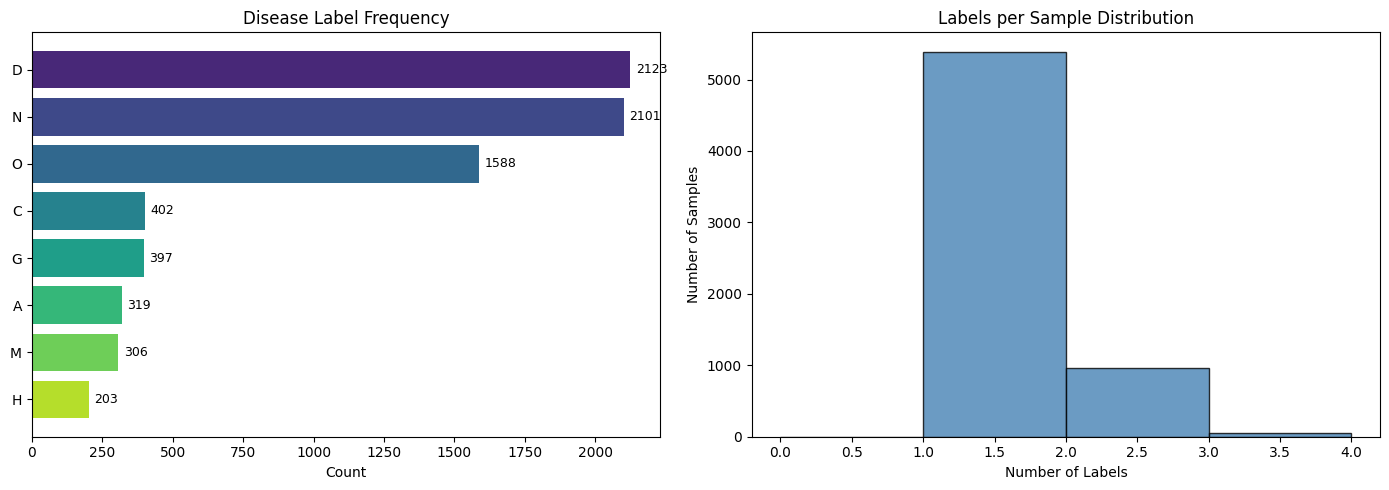

In [6]:
print("=" * 70)
print("📂 Loading ODIR-5K Dataset")
print("=" * 70)

df = pd.read_csv(cfg.CSV_PATH)
print(f"   Total rows: {len(df)}")

# Handle NaN values
nan_counts = df[cfg.DISEASE_COLUMNS].isnull().sum()
total_nans = nan_counts.sum()
if total_nans > 0:
    print(f"\n   ⚠️ Found {total_nans} NaN values in labels — replacing with 0")
    df[cfg.DISEASE_COLUMNS] = df[cfg.DISEASE_COLUMNS].fillna(0)
else:
    print("   ✅ No NaN values in labels")

# Ensure labels are strictly 0 or 1
for col in cfg.DISEASE_COLUMNS:
    df[col] = df[col].astype(float).clip(0, 1).round().astype(int)
print("   ✅ Labels validated (0 or 1)")

# Build image paths
df['image_path'] = df['filename'].apply(lambda fn: os.path.join(cfg.TRAIN_IMG_DIR, fn))
df['exists'] = df['image_path'].apply(os.path.isfile)
missing = (~df['exists']).sum()
if missing > 0:
    print(f"   ⚠️ {missing} images not found — skipping")
df = df[df['exists']].reset_index(drop=True)
print(f"   ✅ Valid samples: {len(df)}")

# Label distribution
print("\n📊 Label Distribution:")
label_counts = df[cfg.DISEASE_COLUMNS].sum().sort_values(ascending=False)
for col, cnt in label_counts.items():
    pct = cnt / len(df) * 100
    name = cfg.DISEASE_NAMES.get(col, col)
    print(f"   {col} ({name:>14s}): {int(cnt):>5d} ({pct:.1f}%)")

labels_per_sample = df[cfg.DISEASE_COLUMNS].sum(axis=1)
print(f"\n   Labels/sample — mean: {labels_per_sample.mean():.2f}, max: {labels_per_sample.max():.0f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = sns.color_palette("viridis", n_colors=cfg.NUM_CLASSES)
axes[0].barh(label_counts.index, label_counts.values, color=colors)
axes[0].set_xlabel("Count")
axes[0].set_title("Disease Label Frequency")
axes[0].invert_yaxis()
for i, v in enumerate(label_counts.values):
    axes[0].text(v + 20, i, str(int(v)), va='center', fontsize=9)

axes[1].hist(labels_per_sample, bins=range(0, int(labels_per_sample.max()) + 2),
             edgecolor='black', color='steelblue', alpha=0.8)
axes[1].set_xlabel("Number of Labels")
axes[1].set_ylabel("Number of Samples")
axes[1].set_title("Labels per Sample Distribution")
plt.tight_layout()
plt.savefig(os.path.join(cfg.REPORTS_DIR, "label_distribution.png"), dpi=150)
plt.show()

In [7]:
print("⚖️  Computing pos_weight for BCEWithLogitsLoss...")
label_array = df[cfg.DISEASE_COLUMNS].values.astype(np.float32)
pos_counts = label_array.sum(axis=0)
neg_counts = len(label_array) - pos_counts
pos_weight = neg_counts / (pos_counts + 1e-6)
pos_weight = np.clip(pos_weight, 1.0, 20.0)
pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float32).to(DEVICE)

print(f"\n   {'Class':>6s} | {'Positive':>8s} | {'Negative':>8s} | {'pos_weight':>10s}")
print("   " + "-" * 48)
for i, col in enumerate(cfg.DISEASE_COLUMNS):
    print(f"   {col:>6s} | {int(pos_counts[i]):>8d} | {int(neg_counts[i]):>8d} | {pos_weight[i]:>10.2f}")

⚖️  Computing pos_weight for BCEWithLogitsLoss...

    Class | Positive | Negative | pos_weight
   ------------------------------------------------
        N |     2101 |     4291 |       2.04
        D |     2123 |     4269 |       2.01
        G |      397 |     5995 |      15.10
        C |      402 |     5990 |      14.90
        A |      319 |     6073 |      19.04
        H |      203 |     6189 |      20.00
        M |      306 |     6086 |      19.89
        O |     1588 |     4804 |       3.03


In [8]:
class CLAHEPreprocess(A.ImageOnlyTransform):
    """CLAHE on LAB luminance channel for retinal image enhancement."""
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8), always_apply=False, p=1.0):
        super().__init__(always_apply, p)
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size

    def apply(self, img, **params):
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        l_channel, a_channel, b_channel = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=self.tile_grid_size)
        l_enhanced = clahe.apply(l_channel)
        lab_enhanced = cv2.merge([l_enhanced, a_channel, b_channel])
        return cv2.cvtColor(lab_enhanced, cv2.COLOR_LAB2RGB)

    def get_transform_init_args_names(self):
        return ("clip_limit", "tile_grid_size")

if cfg.USE_CLAHE:
    print("🔬 CLAHE preprocessing enabled (LAB luminance)")

🔬 CLAHE preprocessing enabled (LAB luminance)


In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Training augmentations
train_transform_list = []
if cfg.USE_CLAHE:
    train_transform_list.append(
        CLAHEPreprocess(clip_limit=cfg.CLAHE_CLIP_LIMIT,
                        tile_grid_size=cfg.CLAHE_TILE_SIZE, p=1.0)
    )
train_transform_list.extend([
    A.Resize(cfg.IMG_SIZE, cfg.IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=15, p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15,
                       border_mode=cv2.BORDER_CONSTANT, p=0.4),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.CoarseDropout(max_holes=4, max_height=20, max_width=20, p=0.2),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])
train_transforms = A.Compose(train_transform_list)

# Validation augmentations (CLAHE + resize + normalize only)
val_transform_list = []
if cfg.USE_CLAHE:
    val_transform_list.append(
        CLAHEPreprocess(clip_limit=cfg.CLAHE_CLIP_LIMIT,
                        tile_grid_size=cfg.CLAHE_TILE_SIZE, p=1.0)
    )
val_transform_list.extend([
    A.Resize(cfg.IMG_SIZE, cfg.IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])
val_transforms = A.Compose(val_transform_list)

print(f"✅ Augmentation pipelines: Train={len(train_transforms.transforms)} transforms, "
      f"Val={len(val_transforms.transforms)} transforms")

✅ Augmentation pipelines: Train=11 transforms, Val=4 transforms


In [10]:
class ODIRDataset(Dataset):
    """ODIR-5K multi-label retinal disease dataset."""

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels.astype(np.float32)
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = cv2.imread(img_path)
        if image is None:
            image = np.zeros((cfg.IMG_SIZE, cfg.IMG_SIZE, 3), dtype=np.uint8)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return image, label

print("✅ ODIRDataset class defined.")

✅ ODIRDataset class defined.


In [11]:
print("=" * 70)
print("📦 Creating SHARED Data Split (same split for all ensemble models)")
print("=" * 70)

image_paths = df['image_path'].values
labels = df[cfg.DISEASE_COLUMNS].values.astype(np.float32)

if HAS_ITERSTRAT:
    mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=cfg.SEED)
    train_idx, val_idx = next(iter(mskf.split(image_paths, labels)))
    X_train, X_val = image_paths[train_idx], image_paths[val_idx]
    y_train, y_val = labels[train_idx], labels[val_idx]
    print("   ✅ MultilabelStratifiedKFold split (iterative stratification)")
else:
    label_freq = labels.sum(axis=0)
    stratify_keys = []
    for row in labels:
        positive_indices = np.where(row == 1)[0]
        if len(positive_indices) == 0:
            stratify_keys.append(cfg.NUM_CLASSES)
        else:
            rarest_idx = positive_indices[np.argmin(label_freq[positive_indices])]
            stratify_keys.append(rarest_idx)
    stratify_keys = np.array(stratify_keys)
    try:
        X_train, X_val, y_train, y_val = train_test_split(
            image_paths, labels, test_size=0.2,
            random_state=cfg.SEED, shuffle=True, stratify=stratify_keys
        )
        print("   ✅ Approximate stratified split")
    except ValueError:
        X_train, X_val, y_train, y_val = train_test_split(
            image_paths, labels, test_size=0.2, random_state=cfg.SEED, shuffle=True
        )
        print("   ⚠️ Fallback to random split")

print(f"   Train: {len(X_train)} | Val: {len(X_val)}")

# Verify label distribution
print(f"\n   {'Class':>6s} | {'Train':>6s} ({'%':>5s}) | {'Val':>5s} ({'%':>5s})")
print("   " + "-" * 50)
for i, col in enumerate(cfg.DISEASE_COLUMNS):
    train_cnt = y_train[:, i].sum()
    val_cnt = y_val[:, i].sum()
    train_pct = train_cnt / len(y_train) * 100
    val_pct = val_cnt / len(y_val) * 100
    val_unique = len(set(y_val[:, i].astype(int)))
    status = "✅" if val_unique > 1 else "🚨"
    print(f"   {col:>6s} | {int(train_cnt):>6d} ({train_pct:>5.1f}%) | "
          f"{int(val_cnt):>5d} ({val_pct:>5.1f}%) {status}")

# WeightedRandomSampler
print("\n⚖️  Computing WeightedRandomSampler...")
train_class_freq = y_train.sum(axis=0)
train_class_weight = 1.0 / (train_class_freq + 1e-6)
sample_weights = np.zeros(len(y_train))
for i in range(len(y_train)):
    positive_mask = y_train[i] == 1
    if positive_mask.any():
        sample_weights[i] = train_class_weight[positive_mask].max()
    else:
        sample_weights[i] = 1.0
sample_weights = sample_weights / sample_weights.sum() * len(sample_weights)
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(y_train),
    replacement=True
)
print(f"   Weight range: [{sample_weights.min():.4f}, {sample_weights.max():.4f}]")

# Create datasets
train_dataset = ODIRDataset(X_train, y_train, transform=train_transforms)
val_dataset = ODIRDataset(X_val, y_val, transform=val_transforms)

worker_kwargs = dict(num_workers=cfg.NUM_WORKERS, pin_memory=cfg.PIN_MEMORY)
if cfg.NUM_WORKERS > 0:
    worker_kwargs['persistent_workers'] = True

train_loader = DataLoader(train_dataset, batch_size=cfg.BATCH_SIZE,
                          sampler=sampler, drop_last=True, **worker_kwargs)
val_loader = DataLoader(val_dataset, batch_size=cfg.BATCH_SIZE,
                        shuffle=False, drop_last=False, **worker_kwargs)

print(f"\n   Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
imgs, lbls = next(iter(train_loader))
print(f"   Batch shape: {imgs.shape}, Labels shape: {lbls.shape}")

📦 Creating SHARED Data Split (same split for all ensemble models)
   ✅ MultilabelStratifiedKFold split (iterative stratification)
   Train: 5104 | Val: 1288

    Class |  Train (    %) |   Val (    %)
   --------------------------------------------------
        N |   1681 ( 32.9%) |   420 ( 32.6%) ✅
        D |   1699 ( 33.3%) |   424 ( 32.9%) ✅
        G |    318 (  6.2%) |    79 (  6.1%) ✅
        C |    321 (  6.3%) |    81 (  6.3%) ✅
        A |    255 (  5.0%) |    64 (  5.0%) ✅
        H |    162 (  3.2%) |    41 (  3.2%) ✅
        M |    245 (  4.8%) |    61 (  4.7%) ✅
        O |   1271 ( 24.9%) |   317 ( 24.6%) ✅

⚖️  Computing WeightedRandomSampler...
   Weight range: [0.4108, 4.3082]

   Train batches: 159 | Val batches: 41
   Batch shape: torch.Size([32, 3, 224, 224]), Labels shape: torch.Size([32, 8])


In [12]:
class MultiLabelClassifier(nn.Module):
    """Generic multi-label classifier using any timm backbone.

    Works with EfficientNet, DenseNet, ConvNeXt, ResNet, etc.
    """

    def __init__(self, backbone_name, num_classes=8, dropout=0.3, pretrained=True):
        super().__init__()
        self.backbone_name = backbone_name
        self.backbone = timm.create_model(
            backbone_name,
            pretrained=pretrained,
            num_classes=0,     # Remove classifier → feature extractor
            drop_rate=0.0,
        )
        in_features = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes),
        )
        print(f"   [{backbone_name}] Feature dim: {in_features}, "
              f"Head: Dropout({dropout}) → Linear({in_features}, {num_classes})")

    def forward(self, x):
        features = self.backbone(x)
        logits = self.head(features)
        return logits

    def freeze_backbone(self):
        """Freeze backbone for Phase 1 (head-only training)."""
        for param in self.backbone.parameters():
            param.requires_grad = False
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"   🧊 [{self.backbone_name}] Backbone FROZEN — trainable: {trainable:,}")

    def unfreeze_backbone(self):
        """Unfreeze backbone for Phase 2 (full fine-tuning)."""
        for param in self.backbone.parameters():
            param.requires_grad = True
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"   🔥 [{self.backbone_name}] Backbone UNFROZEN — trainable: {trainable:,}")

    def get_features(self, x):
        """Extract feature vectors (for analysis/visualization)."""
        return self.backbone(x)

print("✅ MultiLabelClassifier defined (supports any timm backbone).")

✅ MultiLabelClassifier defined (supports any timm backbone).


In [13]:
def safe_auc(y_true, y_pred):
    """Macro ROC-AUC, safely skipping classes with only one label value."""
    aucs = []
    for i in range(y_true.shape[1]):
        unique_labels = set(y_true[:, i].astype(int))
        if len(unique_labels) > 1:
            try:
                a = roc_auc_score(y_true[:, i], y_pred[:, i])
                if not np.isnan(a):
                    aucs.append(a)
            except (ValueError, IndexError):
                continue
    return np.mean(aucs) if aucs else 0.5


def safe_per_class_auc(y_true, y_pred):
    """Per-class AUC, returning 0.5 for degenerate classes."""
    aucs = np.full(y_true.shape[1], 0.5)
    for i in range(y_true.shape[1]):
        unique_labels = set(y_true[:, i].astype(int))
        if len(unique_labels) > 1:
            try:
                aucs[i] = roc_auc_score(y_true[:, i], y_pred[:, i])
                if np.isnan(aucs[i]):
                    aucs[i] = 0.5
            except (ValueError, IndexError):
                aucs[i] = 0.5
    return aucs


def train_one_epoch(model, loader, criterion, optimizer, scaler, device,
                    grad_clip=1.0, use_amp=True):
    """Train for one epoch with AMP and gradient clipping."""
    model.train()
    running_loss = 0.0
    valid_samples = 0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc="  Train", leave=False)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).float()

        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=use_amp):
            logits = model(images)
            loss = criterion(logits, labels)

        if torch.isnan(loss) or torch.isinf(loss):
            optimizer.zero_grad(set_to_none=True)
            continue

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        valid_samples += images.size(0)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_preds.append(probs)
        all_labels.append(labels.cpu().numpy())
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / max(valid_samples, 1)
    all_preds = np.concatenate(all_preds) if all_preds else np.zeros((1, cfg.NUM_CLASSES))
    all_labels = np.concatenate(all_labels) if all_labels else np.zeros((1, cfg.NUM_CLASSES))
    epoch_auc = safe_auc(all_labels, all_preds)
    return epoch_loss, epoch_auc


@torch.no_grad()
def validate(model, loader, criterion, device, use_amp=True):
    """Validate and return metrics + raw predictions."""
    model.eval()
    running_loss = 0.0
    valid_samples = 0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc="  Valid", leave=False)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).float()

        with autocast(enabled=use_amp):
            logits = model(images)
            loss = criterion(logits, labels)

        if torch.isnan(logits).any():
            continue

        loss_val = loss.item()
        if not (np.isnan(loss_val) or np.isinf(loss_val)):
            running_loss += loss_val * images.size(0)
            valid_samples += images.size(0)

        probs = torch.sigmoid(logits).cpu().numpy().astype(np.float32)
        probs = np.clip(probs, 0.0, 1.0)
        all_preds.append(probs)
        all_labels.append(labels.cpu().numpy().astype(np.float32))

    epoch_loss = running_loss / max(valid_samples, 1) if valid_samples > 0 else float('inf')
    all_preds = np.concatenate(all_preds) if all_preds else np.zeros((1, cfg.NUM_CLASSES), dtype=np.float32)
    all_labels = np.concatenate(all_labels) if all_labels else np.zeros((1, cfg.NUM_CLASSES), dtype=np.float32)

    epoch_auc = safe_auc(all_labels, all_preds)
    f1_mac = f1_score(all_labels.astype(int), (all_preds > 0.5).astype(int),
                      average='macro', zero_division=0)
    return epoch_loss, epoch_auc, f1_mac, all_preds, all_labels

print("✅ Training and validation functions defined.")

✅ Training and validation functions defined.


In [14]:
def train_single_model(model_cfg, train_loader, val_loader, criterion,
                       device, cfg_global):
    """
    Train a single model using two-phase training protocol.

    Returns:
        model: Trained model (best weights loaded)
        history: Training history dict
        best_auc: Best validation AUC achieved
        val_preds: Validation predictions from best model
        val_labels: Validation ground truth
    """
    model_name = model_cfg['name']
    print(f"\n{'━' * 70}")
    print(f"🚀 Training: {model_name.upper()}")
    print(f"   LR={model_cfg['lr']}, Warmup={model_cfg['warmup_epochs']}ep, "
          f"Total={model_cfg['total_epochs']}ep")
    print(f"{'━' * 70}")

    # Build model
    model = MultiLabelClassifier(
        backbone_name=model_cfg['timm_name'],
        num_classes=cfg_global.NUM_CLASSES,
        dropout=model_cfg['dropout'],
        pretrained=True,
    ).to(device)

    total_params = sum(p.numel() for p in model.parameters())
    print(f"   Total params: {total_params:,}")

    # Init
    scaler = GradScaler(enabled=cfg_global.USE_AMP)
    history = {
        'train_loss': [], 'val_loss': [],
        'train_auc': [], 'val_auc': [], 'val_f1': [],
        'lr': [], 'phase': []
    }
    best_auc = 0.0
    patience_counter = 0
    best_preds, best_labels = None, None
    best_state = None
    save_path = os.path.join(cfg_global.MODELS_DIR, f"{model_cfg['save_name']}.pth")

    # ════════════════════════ PHASE 1: HEAD WARMUP ════════════════════════
    print(f"\n   🧊 PHASE 1 — Head warmup ({model_cfg['warmup_epochs']} epochs)")
    model.freeze_backbone()

    optimizer_p1 = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=model_cfg['warmup_lr'],
        weight_decay=model_cfg['weight_decay'],
    )
    scheduler_p1 = optim.lr_scheduler.CosineAnnealingLR(
        optimizer_p1, T_max=model_cfg['warmup_epochs'], eta_min=1e-5
    )

    for epoch in range(1, model_cfg['warmup_epochs'] + 1):
        lr = optimizer_p1.param_groups[0]['lr']
        print(f"\n   P1 Epoch {epoch}/{model_cfg['warmup_epochs']} | LR: {lr:.2e}")

        train_loss, train_auc = train_one_epoch(
            model, train_loader, criterion, optimizer_p1, scaler,
            device, cfg_global.GRAD_CLIP_NORM, cfg_global.USE_AMP
        )
        val_loss, val_auc, val_f1, val_preds, val_labels = validate(
            model, val_loader, criterion, device, cfg_global.USE_AMP
        )
        scheduler_p1.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_auc'].append(train_auc)
        history['val_auc'].append(val_auc)
        history['val_f1'].append(val_f1)
        history['lr'].append(lr)
        history['phase'].append(1)

        print(f"   Train — Loss: {train_loss:.4f} | AUC: {train_auc:.4f}")
        print(f"   Valid — Loss: {val_loss:.4f} | AUC: {val_auc:.4f} | F1: {val_f1:.4f}")

        if val_auc > best_auc:
            best_auc = val_auc
            best_preds = val_preds.copy()
            best_labels = val_labels.copy()
            best_state = copy.deepcopy(model.state_dict())
            print(f"   💾 New best (AUC={best_auc:.4f})")

    # ════════════════════════ PHASE 2: FULL FINE-TUNING ════════════════════
    phase2_epochs = model_cfg['total_epochs'] - model_cfg['warmup_epochs']
    print(f"\n   🔥 PHASE 2 — Full fine-tuning ({phase2_epochs} epochs)")
    model.unfreeze_backbone()

    optimizer_p2 = optim.AdamW(
        model.parameters(),
        lr=model_cfg['lr'],
        weight_decay=model_cfg['weight_decay'],
    )
    scheduler_p2 = optim.lr_scheduler.CosineAnnealingLR(
        optimizer_p2, T_max=phase2_epochs, eta_min=1e-7
    )

    patience_counter = 0
    for epoch in range(1, phase2_epochs + 1):
        lr = optimizer_p2.param_groups[0]['lr']
        print(f"\n   P2 Epoch {epoch}/{phase2_epochs} | LR: {lr:.2e}")

        train_loss, train_auc = train_one_epoch(
            model, train_loader, criterion, optimizer_p2, scaler,
            device, cfg_global.GRAD_CLIP_NORM, cfg_global.USE_AMP
        )
        val_loss, val_auc, val_f1, val_preds, val_labels = validate(
            model, val_loader, criterion, device, cfg_global.USE_AMP
        )
        scheduler_p2.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_auc'].append(train_auc)
        history['val_auc'].append(val_auc)
        history['val_f1'].append(val_f1)
        history['lr'].append(lr)
        history['phase'].append(2)

        print(f"   Train — Loss: {train_loss:.4f} | AUC: {train_auc:.4f}")
        print(f"   Valid — Loss: {val_loss:.4f} | AUC: {val_auc:.4f} | F1: {val_f1:.4f}")

        if val_auc > best_auc:
            best_auc = val_auc
            patience_counter = 0
            best_preds = val_preds.copy()
            best_labels = val_labels.copy()
            best_state = copy.deepcopy(model.state_dict())
            print(f"   💾 New best (AUC={best_auc:.4f})")
        else:
            patience_counter += 1
            print(f"   ⏳ No improvement ({patience_counter}/{cfg_global.PATIENCE})")
            if patience_counter >= cfg_global.PATIENCE:
                print(f"\n   🛑 Early stopping (best AUC={best_auc:.4f})")
                break

    # Reload best weights
    if best_state is not None:
        model.load_state_dict(best_state)

    # Save model
    torch.save({
        'model_state_dict': model.state_dict(),
        'backbone_name': model_cfg['timm_name'],
        'best_auc': best_auc,
        'dropout': model_cfg['dropout'],
        'num_classes': cfg_global.NUM_CLASSES,
        'history': history,
    }, save_path)
    print(f"\n   ✅ Model saved: {save_path}")
    print(f"   ✅ Best AUC: {best_auc:.4f}")

    # Save validation predictions for ensemble
    preds_path = os.path.join(cfg_global.MODELS_DIR, f"{model_cfg['save_name']}_val_preds.npy")
    np.save(preds_path, best_preds)
    print(f"   ✅ Val predictions saved: {preds_path}")

    return model, history, best_auc, best_preds, best_labels

print("✅ train_single_model() defined.")

✅ train_single_model() defined.


In [15]:
print("=" * 70)
print("🏋️  ENSEMBLE TRAINING — 3 Models on ODIR-5K")
print("=" * 70)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

all_results = {}
all_val_preds = {}
all_histories = {}
val_labels_shared = None  # same for all models (same split)

total_start = time.time()

for i, model_cfg in enumerate(cfg.MODELS):
    print(f"\n{'█' * 70}")
    print(f"  MODEL {i+1}/{len(cfg.MODELS)}: {model_cfg['name'].upper()}")
    print(f"{'█' * 70}")

    model_start = time.time()

    model, history, best_auc, val_preds, val_labels = train_single_model(
        model_cfg, train_loader, val_loader, criterion, DEVICE, cfg
    )

    model_time = time.time() - model_start
    print(f"\n   ⏱️  Training time: {model_time/60:.1f} minutes")

    all_results[model_cfg['name']] = {
        'best_auc': best_auc,
        'time_minutes': round(model_time / 60, 1),
    }
    all_val_preds[model_cfg['name']] = val_preds
    all_histories[model_cfg['name']] = history
    val_labels_shared = val_labels  # same across all models

    # Free GPU memory before next model
    del model
    torch.cuda.empty_cache()

total_time = time.time() - total_start
print(f"\n{'=' * 70}")
print(f"✅ All 3 models trained in {total_time/60:.1f} minutes ({total_time/3600:.1f} hours)")
print(f"{'=' * 70}")

print(f"\n📊 Individual Model Results:")
print(f"   {'Model':>20s} | {'Best AUC':>10s} | {'Time (min)':>10s}")
print("   " + "-" * 50)
for name, res in all_results.items():
    print(f"   {name:>20s} | {res['best_auc']:>10.4f} | {res['time_minutes']:>10.1f}")

🏋️  ENSEMBLE TRAINING — 3 Models on ODIR-5K

██████████████████████████████████████████████████████████████████████
  MODEL 1/3: EFFICIENTNET_B3
██████████████████████████████████████████████████████████████████████

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🚀 Training: EFFICIENTNET_B3
   LR=3e-05, Warmup=5ep, Total=40ep
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


   [efficientnet_b3] Feature dim: 1536, Head: Dropout(0.3) → Linear(1536, 8)
   Total params: 10,708,528

   🧊 PHASE 1 — Head warmup (5 epochs)
   🧊 [efficientnet_b3] Backbone FROZEN — trainable: 12,296

   P1 Epoch 1/5 | LR: 1.00e-03


  Train:   0%|          | 0/159 [00:00<?, ?it/s]

  Valid:   0%|          | 0/41 [00:00<?, ?it/s]

   Train — Loss: 1.2887 | AUC: 0.7004
   Valid — Loss: 1.0546 | AUC: 0.7375 | F1: 0.2345
   💾 New best (AUC=0.7375)

   P1 Epoch 2/5 | LR: 9.05e-04


...

  Valid:   0%|          | 0/41 [00:00<?, ?it/s]

   Train — Loss: 0.0813 | AUC: 0.9950
   Valid — Loss: 1.7423 | AUC: 0.8554 | F1: 0.5911
   ⏳ No improvement (7/8)

   P2 Epoch 21/35 | LR: 1.95e-05


  Train:   0%|          | 0/159 [00:00<?, ?it/s]

  Valid:   0%|          | 0/41 [00:00<?, ?it/s]

   Train — Loss: 0.0764 | AUC: 0.9958
   Valid — Loss: 1.7190 | AUC: 0.8596 | F1: 0.6070
   ⏳ No improvement (8/8)

   🛑 Early stopping (best AUC=0.8628)

   ✅ Model saved: /content/drive/MyDrive/odir/ensemble_output/models/ensemble_convnext_tiny.pth
   ✅ Best AUC: 0.8628
   ✅ Val predictions saved: /content/drive/MyDrive/odir/ensemble_output/models/ensemble_convnext_tiny_val_preds.npy

   ⏱️  Training time: 31.6 minutes

✅ All 3 models trained in 111.2 minutes (1.9 hours)

📊 Individual Model Results:
                  Model |   Best AUC | Time (min)
   --------------------------------------------------
        efficientnet_b3 |     0.8234 |       38.6
            densenet121 |     0.8255 |       40.9
          convnext_tiny |     0.8628 |       31.6


In [16]:
print("=" * 70)
print("🔗 ENSEMBLE COMBINATION")
print("=" * 70)

model_names = list(all_val_preds.keys())
preds_list = [all_val_preds[name] for name in model_names]
y_true = val_labels_shared.astype(int)

# ─── Method 1: Equal Weighted Average ───
print("\n📐 Method 1: Equal Weighted Average")
equal_preds = np.mean(preds_list, axis=0)
equal_auc = safe_auc(y_true, equal_preds)
equal_per_class_auc = safe_per_class_auc(y_true, equal_preds)
print(f"   Equal Ensemble AUC: {equal_auc:.4f}")

# ─── Method 2: AUC-Weighted Average ───
print("\n📐 Method 2: AUC-Weighted Average")
aucs = [all_results[name]['best_auc'] for name in model_names]
auc_total = sum(aucs)
auc_weights = [a / auc_total for a in aucs]

weighted_preds = np.zeros_like(preds_list[0])
for w, p, name in zip(auc_weights, preds_list, model_names):
    weighted_preds += w * p
    print(f"   {name:>20s}: weight={w:.4f} (AUC={all_results[name]['best_auc']:.4f})")

weighted_auc = safe_auc(y_true, weighted_preds)
weighted_per_class_auc = safe_per_class_auc(y_true, weighted_preds)
print(f"   Weighted Ensemble AUC: {weighted_auc:.4f}")

# ─── Method 3: Per-Class AUC Weighted ───
print("\n📐 Method 3: Per-Class AUC Weighted Average")
per_class_aucs = {}
for name, preds in zip(model_names, preds_list):
    per_class_aucs[name] = safe_per_class_auc(y_true, preds)
    print(f"   {name:>20s} per-class AUC: {per_class_aucs[name]}")

per_class_preds = np.zeros_like(preds_list[0])
per_class_weights_array = np.zeros((len(model_names), cfg.NUM_CLASSES))

for c in range(cfg.NUM_CLASSES):
    class_aucs = [per_class_aucs[name][c] for name in model_names]
    class_total = sum(class_aucs)
    class_weights = [a / class_total for a in class_aucs]
    for j, (w, p) in enumerate(zip(class_weights, preds_list)):
        per_class_preds[:, c] += w * p[:, c]
        per_class_weights_array[j, c] = w

per_class_auc_ensemble = safe_auc(y_true, per_class_preds)
per_class_auc_per_class = safe_per_class_auc(y_true, per_class_preds)
print(f"   Per-Class Weighted Ensemble AUC: {per_class_auc_ensemble:.4f}")

# ─── Pick Best Ensemble Method ───
print("\n" + "=" * 60)
print("🏆 ENSEMBLE METHOD COMPARISON")
print("=" * 60)
methods = {
    "Equal Average": {"auc": equal_auc, "preds": equal_preds, "per_class": equal_per_class_auc},
    "AUC-Weighted": {"auc": weighted_auc, "preds": weighted_preds, "per_class": weighted_per_class_auc},
    "Per-Class AUC": {"auc": per_class_auc_ensemble, "preds": per_class_preds, "per_class": per_class_auc_per_class},
}

# Add individual models for comparison
for name in model_names:
    ind_auc = all_results[name]['best_auc']
    ind_per_class = safe_per_class_auc(y_true, all_val_preds[name])
    methods[f"[Single] {name}"] = {"auc": ind_auc, "preds": all_val_preds[name], "per_class": ind_per_class}

print(f"\n   {'Method':<30s} | {'Macro AUC':>10s}")
print("   " + "-" * 45)
for method_name, data in sorted(methods.items(), key=lambda x: x[1]['auc'], reverse=True):
    marker = " 🏆" if data['auc'] == max(d['auc'] for d in methods.values()) else ""
    print(f"   {method_name:<30s} | {data['auc']:>10.4f}{marker}")

# Select best ensemble for threshold optimization
best_method_name = max(
    [(k, v) for k, v in methods.items() if not k.startswith("[Single]")],
    key=lambda x: x[1]['auc']
)[0]
best_ensemble_preds = methods[best_method_name]['preds']
best_ensemble_auc = methods[best_method_name]['auc']
print(f"\n   ✅ Selected: {best_method_name} (AUC={best_ensemble_auc:.4f})")

🔗 ENSEMBLE COMBINATION

📐 Method 1: Equal Weighted Average
   Equal Ensemble AUC: 0.8594

📐 Method 2: AUC-Weighted Average
        efficientnet_b3: weight=0.3278 (AUC=0.8234)
            densenet121: weight=0.3287 (AUC=0.8255)
          convnext_tiny: weight=0.3435 (AUC=0.8628)
   Weighted Ensemble AUC: 0.8598

📐 Method 3: Per-Class AUC Weighted Average
        efficientnet_b3 per-class AUC: [0.69689626 0.72780862 0.90138832 0.945365   0.84413935 0.89210202
 0.96020549 0.61920132]
            densenet121 per-class AUC: [0.68837777 0.73965294 0.91976317 0.95168104 0.86642795 0.87117374
 0.94076583 0.62626419]
          convnext_tiny per-class AUC: [0.73392171 0.79140325 0.93991268 0.95764419 0.91764323 0.88790659
 0.96259035 0.71116316]
   Per-Class Weighted Ensemble AUC: 0.8600

🏆 ENSEMBLE METHOD COMPARISON

   Method                         |  Macro AUC
   ---------------------------------------------
   [Single] convnext_tiny         |     0.8628 🏆
   Per-Class AUC                  |

In [17]:
print("=" * 70)
print("🎯 Ensemble Threshold Optimization (maximizing F1 per class)")
print("=" * 70)

optimal_thresholds = {}
print(f"\n   {'Class':>6s} | {'OptThresh':>9s} | {'F1@0.5':>7s} | {'F1@Opt':>7s} | {'Δ':>7s}")
print("   " + "-" * 55)

for i, col in enumerate(cfg.DISEASE_COLUMNS):
    best_f1 = 0.0
    best_thresh = 0.5

    for thresh in np.arange(0.05, 0.95, 0.005):  # Finer search for ensemble
        preds_binary = (best_ensemble_preds[:, i] >= thresh).astype(int)
        f1 = f1_score(y_true[:, i], preds_binary, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh

    f1_default = f1_score(y_true[:, i],
                          (best_ensemble_preds[:, i] >= 0.5).astype(int),
                          zero_division=0)
    optimal_thresholds[col] = round(float(best_thresh), 3)
    delta = best_f1 - f1_default
    print(f"   {col:>6s} | {best_thresh:>9.3f} | {f1_default:>7.4f} | {best_f1:>7.4f} | "
          f"{'+' if delta >= 0 else ''}{delta:>6.4f}")

# Save thresholds
thresh_path = os.path.join(cfg.REPORTS_DIR, "ensemble_optimal_thresholds.json")
with open(thresh_path, 'w') as f:
    json.dump(optimal_thresholds, f, indent=2)
print(f"\n   ✅ Saved: {thresh_path}")

🎯 Ensemble Threshold Optimization (maximizing F1 per class)

    Class | OptThresh |  F1@0.5 |  F1@Opt |       Δ
   -------------------------------------------------------
        N |     0.270 |  0.5569 |  0.5917 | +0.0348
        D |     0.330 |  0.5808 |  0.6203 | +0.0394
        G |     0.835 |  0.5376 |  0.6260 | +0.0883
        C |     0.780 |  0.6601 |  0.7485 | +0.0884
        A |     0.725 |  0.5422 |  0.6555 | +0.1133
        H |     0.550 |  0.4000 |  0.4330 | +0.0330
        M |     0.945 |  0.7704 |  0.8596 | +0.0893
        O |     0.545 |  0.4720 |  0.4894 | +0.0175

   ✅ Saved: /content/drive/MyDrive/odir/ensemble_output/reports/ensemble_optimal_thresholds.json


In [18]:
print("=" * 70)
print("📊 FINAL ENSEMBLE EVALUATION")
print("=" * 70)

opt_thresh_array = np.array([optimal_thresholds[c] for c in cfg.DISEASE_COLUMNS])
y_pred_opt = (best_ensemble_preds >= opt_thresh_array).astype(int)

# Metrics
f1_mac = f1_score(y_true, y_pred_opt, average='macro', zero_division=0)
f1_mic = f1_score(y_true, y_pred_opt, average='micro', zero_division=0)
prec_mac = precision_score(y_true, y_pred_opt, average='macro', zero_division=0)
rec_mac = recall_score(y_true, y_pred_opt, average='macro', zero_division=0)
h_loss = hamming_loss(y_true, y_pred_opt)
auc_macro = safe_auc(y_true, best_ensemble_preds)
auc_per_class_final = safe_per_class_auc(y_true, best_ensemble_preds)

# Per-class F1
per_class_f1 = []
for i in range(cfg.NUM_CLASSES):
    f1_i = f1_score(y_true[:, i], y_pred_opt[:, i], zero_division=0)
    per_class_f1.append(f1_i)

# Summary
print(f"\n{'Metric':<25s} | {'Ensemble':>10s}")
print("-" * 40)
print(f"{'ROC-AUC (Macro)':<25s} | {auc_macro:>10.4f}")
print(f"{'F1 Score (Macro)':<25s} | {f1_mac:>10.4f}")
print(f"{'F1 Score (Micro)':<25s} | {f1_mic:>10.4f}")
print(f"{'Precision (Macro)':<25s} | {prec_mac:>10.4f}")
print(f"{'Recall (Macro)':<25s} | {rec_mac:>10.4f}")
print(f"{'Hamming Loss':<25s} | {h_loss:>10.4f}")

# Comparison: Individual vs Ensemble
print(f"\n\n🏆 INDIVIDUAL vs ENSEMBLE COMPARISON")
print(f"{'─' * 80}")
header = f"   {'Class':>6s}"
for name in model_names:
    header += f" | {name[:12]:>12s}"
header += f" | {'ENSEMBLE':>12s}"
print(header)
print("   " + "-" * (18 * (len(model_names) + 1) + 8))

for i, col in enumerate(cfg.DISEASE_COLUMNS):
    row = f"   {col:>6s}"
    for name in model_names:
        ind_auc_i = safe_per_class_auc(y_true, all_val_preds[name])[i]
        row += f" | {ind_auc_i:>12.4f}"
    row += f" | {auc_per_class_final[i]:>12.4f}"
    # Mark improvement
    best_individual = max(safe_per_class_auc(y_true, all_val_preds[name])[i] for name in model_names)
    if auc_per_class_final[i] > best_individual:
        row += " ✅"
    print(row)

# Macro row
row = f"   {'MACRO':>6s}"
for name in model_names:
    row += f" | {all_results[name]['best_auc']:>12.4f}"
row += f" | {auc_macro:>12.4f}"
best_ind_macro = max(all_results[name]['best_auc'] for name in model_names)
if auc_macro > best_ind_macro:
    row += " 🏆"
print(row)
print(f"\n   Ensemble improvement over best individual: "
      f"{auc_macro - best_ind_macro:+.4f} AUC")

# Classification report
report = classification_report(y_true, y_pred_opt, target_names=cfg.DISEASE_COLUMNS, zero_division=0)
print(f"\n📋 Classification Report:\n{report}")

# Save comprehensive metrics
ensemble_metrics = {
    'ensemble_method': best_method_name,
    'auc_macro': round(float(auc_macro), 4),
    'f1_macro': round(float(f1_mac), 4),
    'f1_micro': round(float(f1_mic), 4),
    'precision_macro': round(float(prec_mac), 4),
    'recall_macro': round(float(rec_mac), 4),
    'hamming_loss': round(float(h_loss), 4),
    'per_class_auc': {col: round(float(auc_per_class_final[i]), 4)
                      for i, col in enumerate(cfg.DISEASE_COLUMNS)},
    'per_class_f1': {col: round(float(per_class_f1[i]), 4)
                     for i, col in enumerate(cfg.DISEASE_COLUMNS)},
    'optimal_thresholds': optimal_thresholds,
    'individual_model_aucs': {name: round(res['best_auc'], 4)
                              for name, res in all_results.items()},
    'training_time_minutes': round(total_time / 60, 1),
    'models': [m['name'] for m in cfg.MODELS],
}

metrics_path = os.path.join(cfg.REPORTS_DIR, "ensemble_metrics.json")
with open(metrics_path, 'w') as f:
    json.dump(ensemble_metrics, f, indent=2)

report_path = os.path.join(cfg.REPORTS_DIR, "ensemble_classification_report.txt")
with open(report_path, 'w') as f:
    f.write(f"Ensemble: {best_method_name}\n")
    f.write(f"Models: {', '.join(m['name'] for m in cfg.MODELS)}\n")
    f.write(f"Thresholds: {optimal_thresholds}\n\n")
    f.write(report)

print(f"\n💾 Reports saved to {cfg.REPORTS_DIR}/")

📊 FINAL ENSEMBLE EVALUATION

Metric                    |   Ensemble
----------------------------------------
ROC-AUC (Macro)           |     0.8600
F1 Score (Macro)          |     0.6280
F1 Score (Micro)          |     0.5962
Precision (Macro)         |     0.6192
Recall (Macro)            |     0.6774
Hamming Loss              |     0.1439


🏆 INDIVIDUAL vs ENSEMBLE COMPARISON
────────────────────────────────────────────────────────────────────────────────
    Class | efficientnet |  densenet121 | convnext_tin |     ENSEMBLE
   --------------------------------------------------------------------------------
        N |       0.6969 |       0.6884 |       0.7339 |       0.7264
        D |       0.7278 |       0.7397 |       0.7914 |       0.7937 ✅
        G |       0.9014 |       0.9198 |       0.9399 |       0.9374
        C |       0.9454 |       0.9517 |       0.9576 |       0.9597 ✅
        A |       0.8441 |       0.8664 |       0.9176 |       0.8943
        H |       0.8921 |    

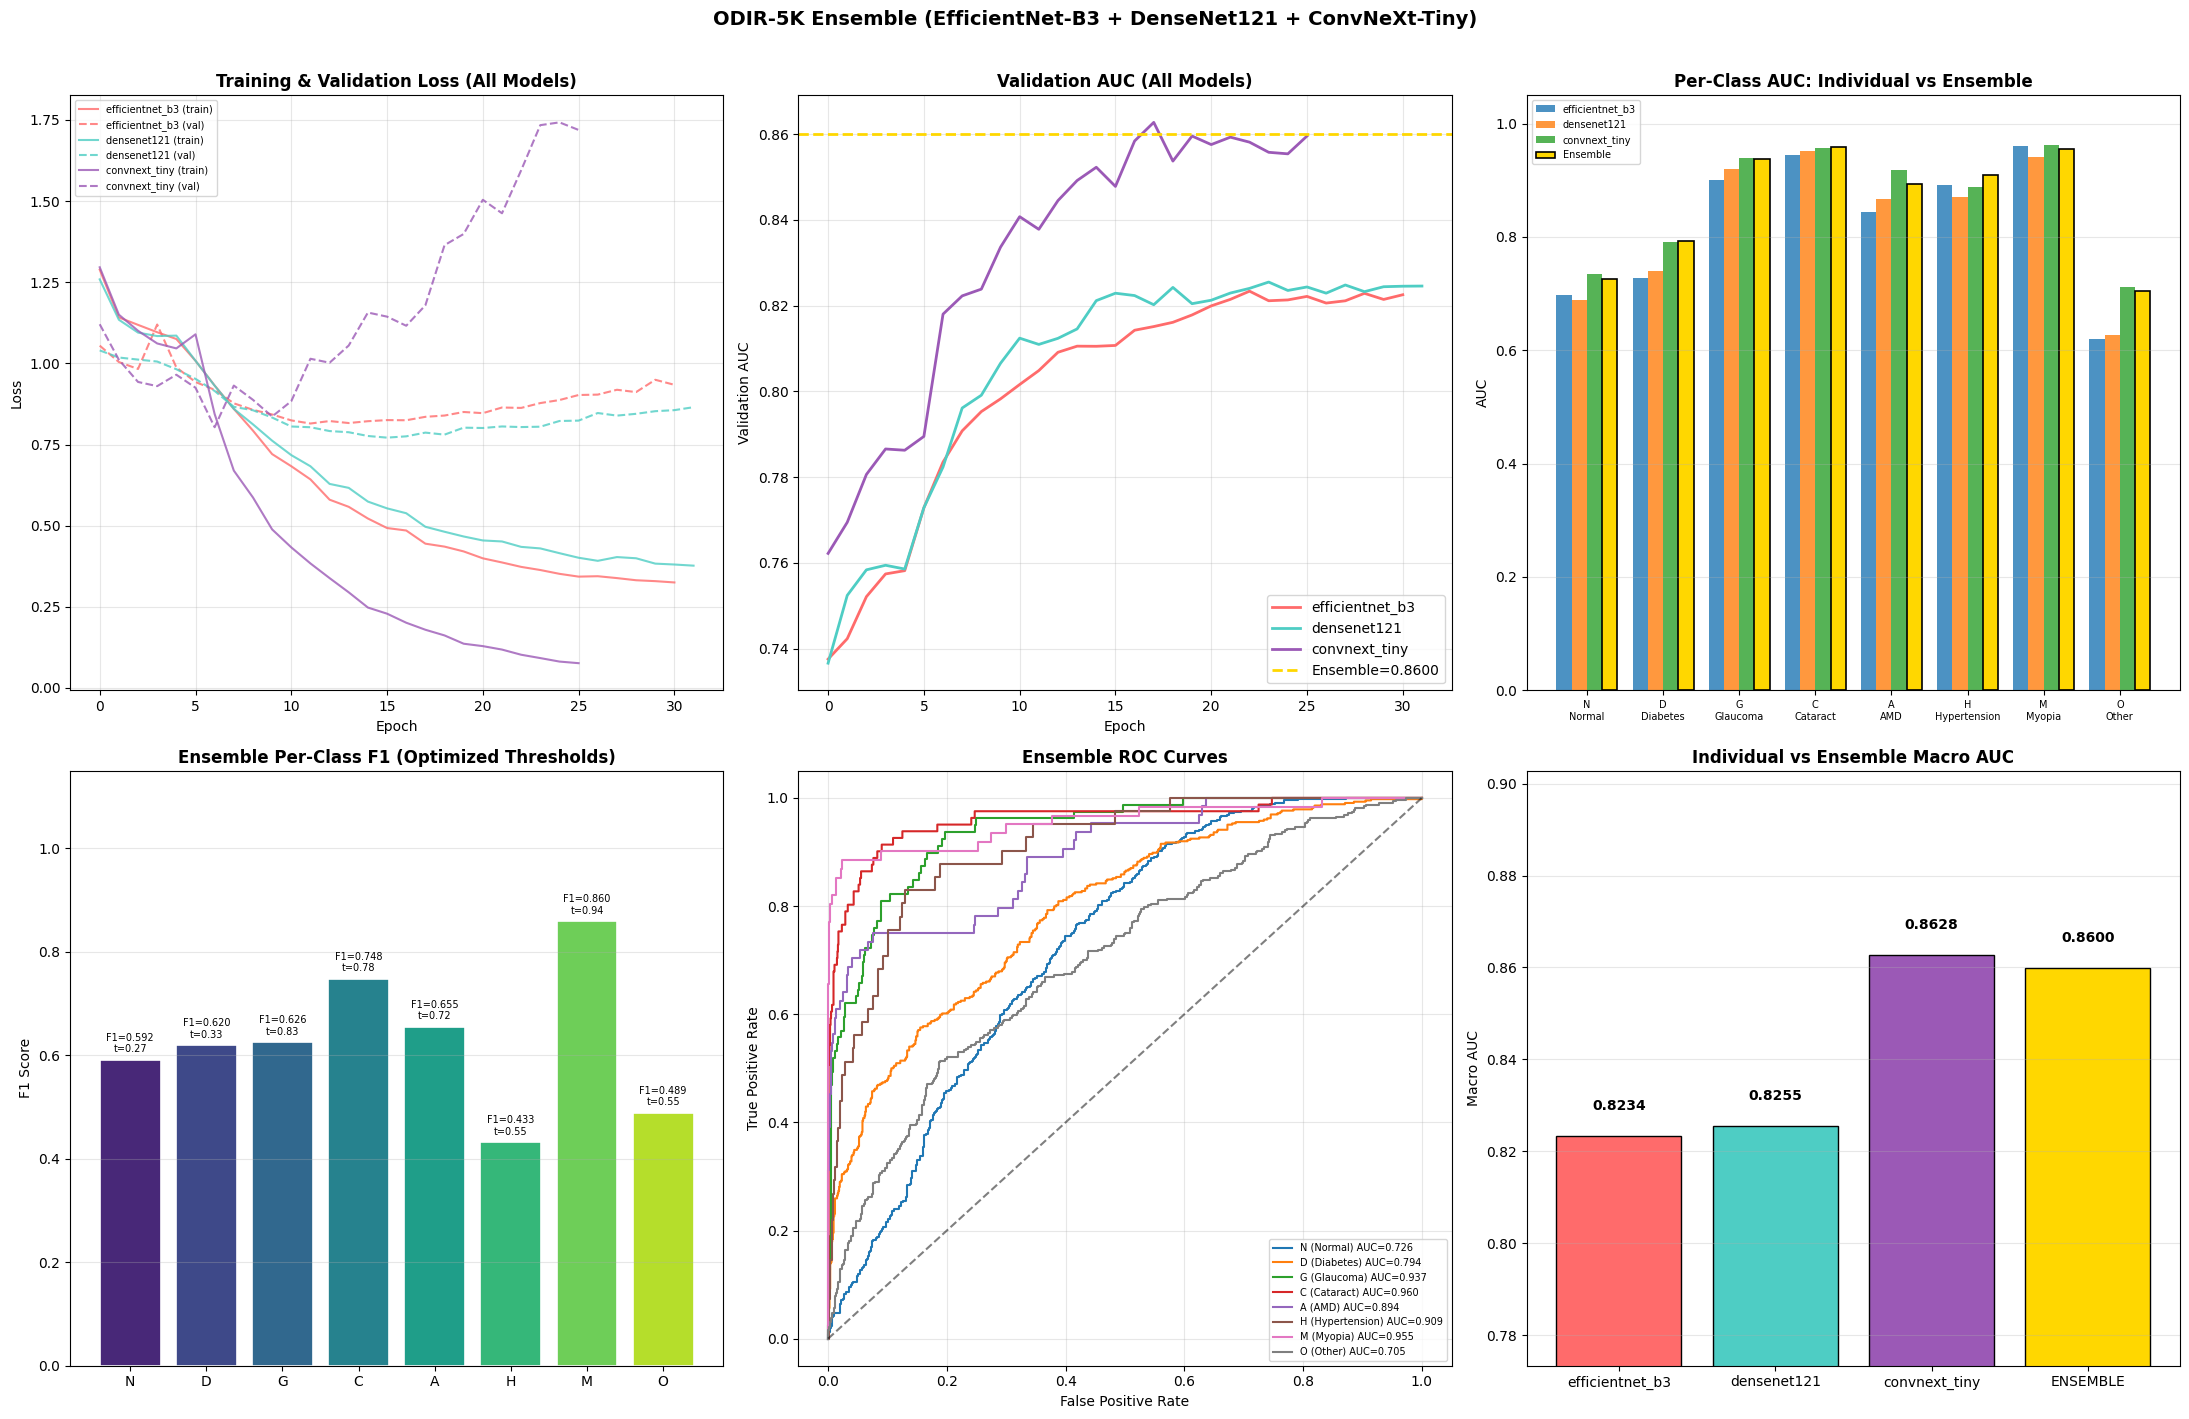

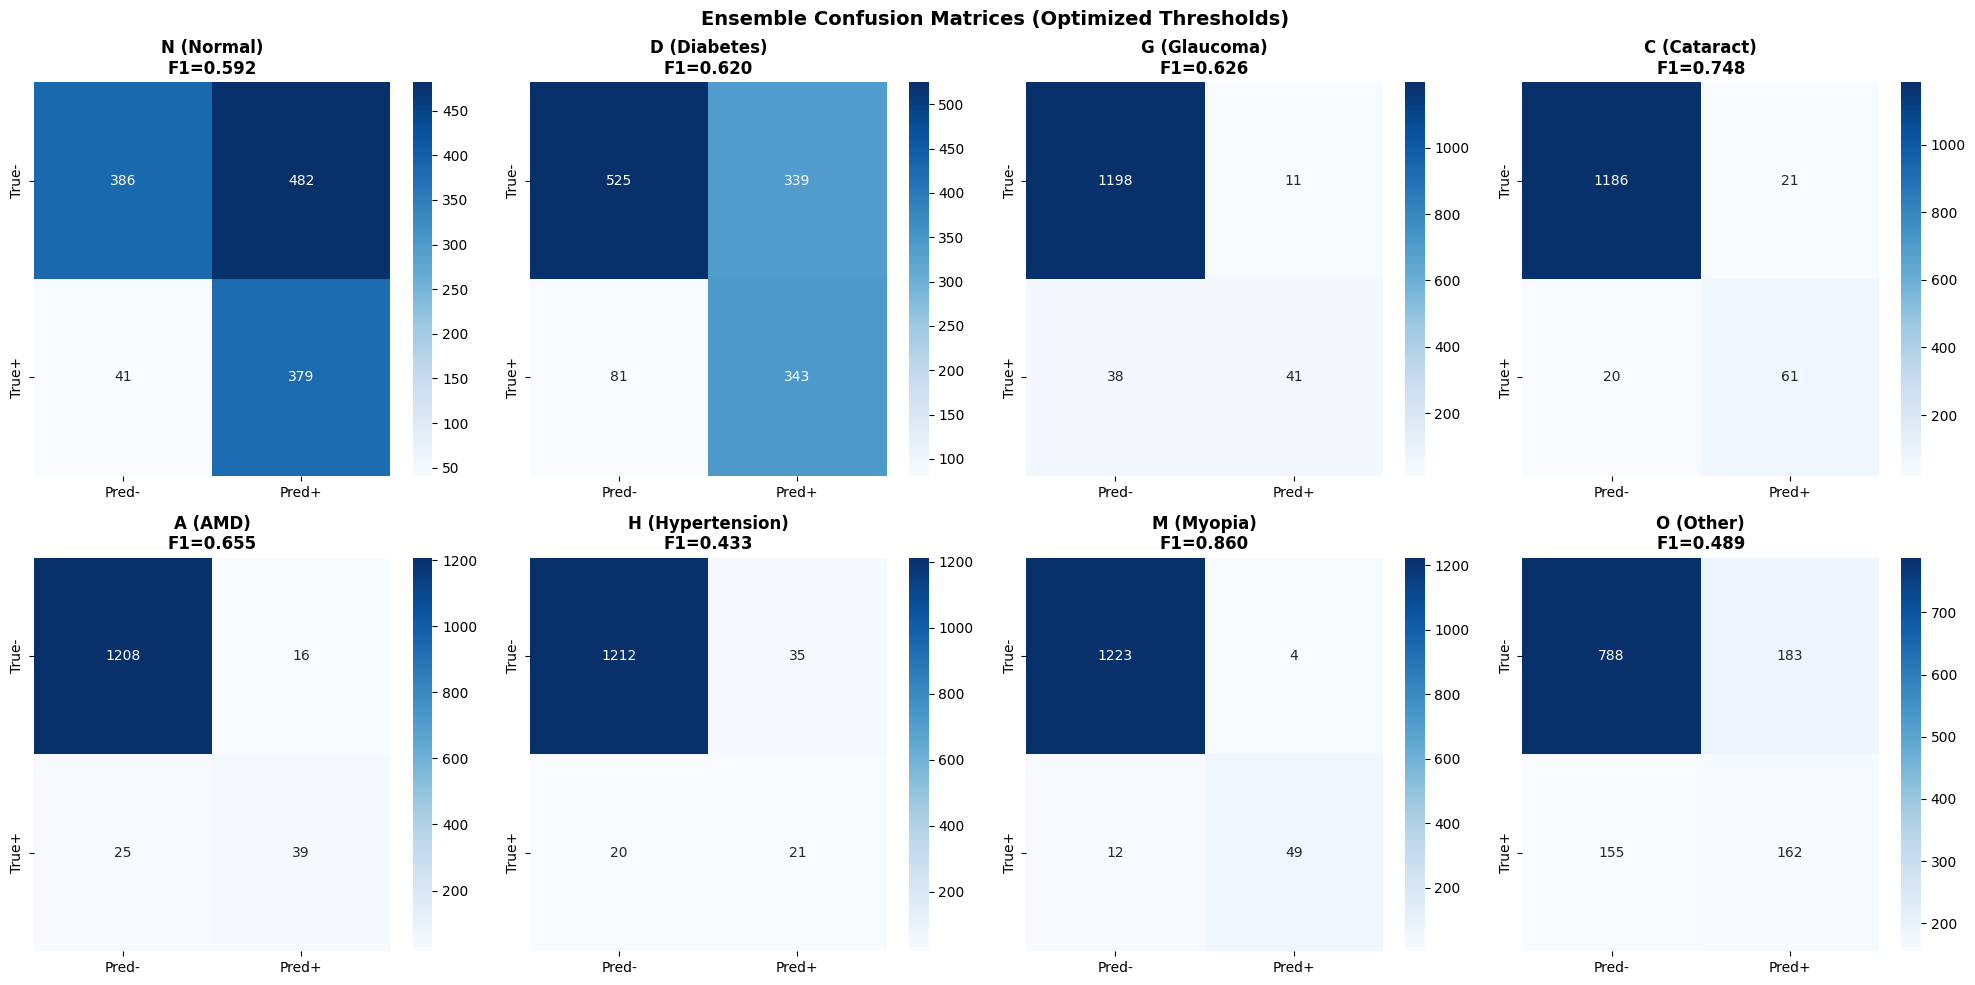

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(22, 14))

# 18a: Loss curves for all models
ax = axes[0, 0]
colors_models = ['#FF6B6B', '#4ECDC4', '#9B59B6']
for idx, (name, hist) in enumerate(all_histories.items()):
    ax.plot(hist['train_loss'], label=f'{name} (train)', color=colors_models[idx],
            linestyle='-', alpha=0.8, linewidth=1.5)
    ax.plot(hist['val_loss'], label=f'{name} (val)', color=colors_models[idx],
            linestyle='--', alpha=0.8, linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss (All Models)', fontweight='bold')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# 18b: AUC curves for all models
ax = axes[0, 1]
for idx, (name, hist) in enumerate(all_histories.items()):
    ax.plot(hist['val_auc'], label=f'{name}', color=colors_models[idx],
            linewidth=2)
ax.axhline(y=best_ensemble_auc, color='gold', linestyle='--', linewidth=2,
           label=f'Ensemble={best_ensemble_auc:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation AUC')
ax.set_title('Validation AUC (All Models)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 18c: Per-class AUC comparison (Individual vs Ensemble)
ax = axes[0, 2]
x = np.arange(cfg.NUM_CLASSES)
width = 0.2
for idx, name in enumerate(model_names):
    ind_aucs = safe_per_class_auc(y_true, all_val_preds[name])
    ax.bar(x + idx * width, ind_aucs, width, label=name, alpha=0.8)
ax.bar(x + len(model_names) * width, auc_per_class_final, width,
       label='Ensemble', color='gold', edgecolor='black', linewidth=1.2)
ax.set_xticks(x + width * len(model_names) / 2)
ax.set_xticklabels([f"{c}\n{cfg.DISEASE_NAMES[c]}" for c in cfg.DISEASE_COLUMNS],
                   fontsize=7)
ax.set_ylabel('AUC')
ax.set_title('Per-Class AUC: Individual vs Ensemble', fontweight='bold')
ax.legend(fontsize=7)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

# 18d: Ensemble per-class F1 with thresholds
ax = axes[1, 0]
bars = ax.bar(cfg.DISEASE_COLUMNS, per_class_f1,
              color=sns.color_palette("viridis", cfg.NUM_CLASSES),
              edgecolor='white', linewidth=1.2)
for bar, val, thresh in zip(bars, per_class_f1, opt_thresh_array):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'F1={val:.3f}\nt={thresh:.2f}', ha='center', va='bottom', fontsize=7)
ax.set_ylabel('F1 Score')
ax.set_title('Ensemble Per-Class F1 (Optimized Thresholds)', fontweight='bold')
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)

# 18e: ROC Curves for ensemble
ax = axes[1, 1]
for i, col in enumerate(cfg.DISEASE_COLUMNS):
    if len(set(y_true[:, i])) > 1:
        fpr, tpr, _ = roc_curve(y_true[:, i], best_ensemble_preds[:, i])
        roc_auc_i = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{col} ({cfg.DISEASE_NAMES[col]}) AUC={roc_auc_i:.3f}",
                linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Ensemble ROC Curves', fontweight='bold')
ax.legend(fontsize=7, loc='lower right')
ax.grid(alpha=0.3)

# 18f: Summary comparison bar chart
ax = axes[1, 2]
model_labels = model_names + ['ENSEMBLE']
macro_aucs = [all_results[name]['best_auc'] for name in model_names] + [best_ensemble_auc]
bar_colors = colors_models + ['gold']
bars = ax.bar(model_labels, macro_aucs, color=bar_colors, edgecolor='black', linewidth=1)
for bar, val in zip(bars, macro_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Macro AUC')
ax.set_title('Individual vs Ensemble Macro AUC', fontweight='bold')
ax.set_ylim(min(macro_aucs) - 0.05, max(macro_aucs) + 0.04)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('ODIR-5K Ensemble (EfficientNet-B3 + DenseNet121 + ConvNeXt-Tiny)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(cfg.REPORTS_DIR, "ensemble_training_summary.png"),
            dpi=200, bbox_inches='tight')
plt.show()

# Confusion Matrices for Ensemble
fig, axes_cm = plt.subplots(2, 4, figsize=(20, 10))
cm = multilabel_confusion_matrix(y_true, y_pred_opt)
for i, (ax, col) in enumerate(zip(axes_cm.flatten(), cfg.DISEASE_COLUMNS)):
    sns.heatmap(cm[i], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred-', 'Pred+'], yticklabels=['True-', 'True+'])
    ax.set_title(f'{col} ({cfg.DISEASE_NAMES[col]})\nF1={per_class_f1[i]:.3f}',
                 fontweight='bold')
plt.suptitle('Ensemble Confusion Matrices (Optimized Thresholds)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(cfg.REPORTS_DIR, "ensemble_confusion_matrices.png"),
            dpi=150, bbox_inches='tight')
plt.show()

In [20]:
print("=" * 70)
print("💾 SAVING FINAL ENSEMBLE CHECKPOINT")
print("=" * 70)

# Save ensemble configuration for production use
ensemble_checkpoint = {
    'ensemble_method': best_method_name,
    'models': [],
    'ensemble_optimal_thresholds': optimal_thresholds,
    'ensemble_auc': best_ensemble_auc,
    'ensemble_metrics': ensemble_metrics,
    'disease_columns': cfg.DISEASE_COLUMNS,
    'img_size': cfg.IMG_SIZE,
    'use_clahe': cfg.USE_CLAHE,
}

for model_cfg in cfg.MODELS:
    model_path = os.path.join(cfg.MODELS_DIR, f"{model_cfg['save_name']}.pth")
    ensemble_checkpoint['models'].append({
        'name': model_cfg['name'],
        'timm_name': model_cfg['timm_name'],
        'weight_path': model_path,
        'dropout': model_cfg['dropout'],
        'best_auc': all_results[model_cfg['name']]['best_auc'],
    })

# AUC weights for production inference
if best_method_name == "AUC-Weighted":
    ensemble_checkpoint['model_weights'] = {
        name: round(w, 4) for name, w in zip(model_names, auc_weights)
    }
elif best_method_name == "Per-Class AUC":
    ensemble_checkpoint['per_class_weights'] = {
        col: {name: round(float(per_class_weights_array[j, i]), 4)
              for j, name in enumerate(model_names)}
        for i, col in enumerate(cfg.DISEASE_COLUMNS)
    }
else:
    ensemble_checkpoint['model_weights'] = {
        name: round(1.0 / len(model_names), 4) for name in model_names
    }

ensemble_config_path = os.path.join(cfg.MODELS_DIR, "ensemble_config.json")
with open(ensemble_config_path, 'w') as f:
    json.dump(ensemble_checkpoint, f, indent=2)

print(f"\n   ✅ Ensemble config: {ensemble_config_path}")
print(f"   ✅ Individual models: {cfg.MODELS_DIR}/")
print(f"   ✅ Reports: {cfg.REPORTS_DIR}/")

# Summary
print(f"\n{'=' * 70}")
print(f"🎯 ENSEMBLE TRAINING COMPLETE")
print(f"{'=' * 70}")
print(f"   Method: {best_method_name}")
print(f"   Models: {', '.join(m['name'] for m in cfg.MODELS)}")
print(f"   Ensemble AUC: {best_ensemble_auc:.4f}")
print(f"   Best Individual: {max(all_results[n]['best_auc'] for n in model_names):.4f} "
      f"({max(all_results, key=lambda n: all_results[n]['best_auc'])})")
print(f"   Improvement: {best_ensemble_auc - max(all_results[n]['best_auc'] for n in model_names):+.4f}")
print(f"   Total training time: {total_time/60:.1f} min ({total_time/3600:.1f} hours)")
print(f"\n   📦 Files to download for production:")
print(f"      1. {ensemble_config_path}")
for m in cfg.MODELS:
    print(f"      2. {os.path.join(cfg.MODELS_DIR, m['save_name'] + '.pth')}")
print(f"\n   Copy these to your project's models/ directory for inference.")

💾 SAVING FINAL ENSEMBLE CHECKPOINT

   ✅ Ensemble config: /content/drive/MyDrive/odir/ensemble_output/models/ensemble_config.json
   ✅ Individual models: /content/drive/MyDrive/odir/ensemble_output/models/
   ✅ Reports: /content/drive/MyDrive/odir/ensemble_output/reports/

🎯 ENSEMBLE TRAINING COMPLETE
   Method: Per-Class AUC
   Models: efficientnet_b3, densenet121, convnext_tiny
   Ensemble AUC: 0.8600
   Best Individual: 0.8628 (convnext_tiny)
   Improvement: -0.0028
   Total training time: 111.2 min (1.9 hours)

   📦 Files to download for production:
      1. /content/drive/MyDrive/odir/ensemble_output/models/ensemble_config.json
      2. /content/drive/MyDrive/odir/ensemble_output/models/ensemble_efficientnet_b3.pth
      2. /content/drive/MyDrive/odir/ensemble_output/models/ensemble_densenet121.pth
      2. /content/drive/MyDrive/odir/ensemble_output/models/ensemble_convnext_tiny.pth

   Copy these to your project's models/ directory for inference.
